# Peptide → protein summarization & the DIA workflow

A DDA or DIA search engine (MaxQuant, FragPipe, DIA-NN, Spectronaut) does **not** report protein abundances directly. Its primary output is a long table of **feature-level** intensities — one row per *precursor* (peptide + charge) or per *fragment ion* (peptide + charge + transition), measured in every run. A single protein is observed through *many* such features, and the number, identity and quality of those features differ from run to run.

Before any differential test you must **summarize** these features into one number per protein per run. This step is not a formality: it is where most of the systematic bias in a label-free experiment is introduced or removed.

Why a naive mean is wrong:

* **Outlier features.** A mis-identified or interfered transition can be 100× off. On the linear scale a single outlier dominates the mean; even on the log scale it shifts it noticeably.
* **Missing features.** Features drop out non-randomly (low-abundance precursors near the detection limit). A protein quantified by its 3 *brightest* features in run A and by 8 features including dim ones in run B will look artificially different — a pure *feature-composition* effect, not biology.
* **Run effects.** Total ion current, LC drift and injection amount vary between runs. These must be modelled per run, not averaged away.

The robust summarizers below all share one idea: model the feature-by-run matrix of one protein as `abundance ≈ feature_effect + run_effect`, estimate it robustly, and read off the **run effects** as the protein abundance. This tutorial compares five methods on a real controlled **DDA spike-in** experiment, then repeats the identical workflow on a real **DIA** dataset.

| Method | Backend | Model | When to use |
|---|---|---|---|
| `median` | `pydeqms` | per-protein median across features | quick, fully missing-tolerant; ignores feature effects |
| `median_sweeping` | `pydeqms` | subtract per-feature median, then median across features | TMT-style; removes feature offsets before collapsing |
| `medpolish` | `pydeqms` | Tukey median polish (robust row+column fit) | robust to outlier features; DEqMS default |
| `tmp` | `pymsstats` | Tukey median polish, MSstats formulation | the **MSstats default** for DDA/DIA |
| `linear` | `pymsstats` | least-squares `ABUNDANCE ~ RUN + FEATURE` | legacy MSstats; sensitive to outliers |

We also run the full MSstats `dataProcess` pipeline (log-transform + per-run normalization + feature selection + TMP summarization in one call) and finish with differential expression on the summarized protein matrix.

## 0. Imports

In [1]:
import omicverse as ov
import pandas as pd
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt

print('core imports ok')

core imports ok


In [2]:
import pymsstats
import pydeqms

ov.plot_set()
print('omicverse', ov.__version__, '| pymsstats', pymsstats.__name__, '| pydeqms', pydeqms.__name__)

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
🚫 No GPU devices found (CUDA/MPS/ROCm/XPU)

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

omicverse 2.2.1rc1 | pymsstats pymsstats | pydeqms pydeqms


## 1. Feature-level DDA data

`ov.datasets.protein_dda_spikein()` returns the MSstats `DDARawData` dataset — a real, controlled label-free **DDA** spike-in experiment. Six purified proteins were spiked into a constant background at six different concentrations (`C1`…`C6`, a dilution series), so the *true* protein-level fold changes are known by design. Each condition has three technical runs (18 runs total).

The table is in **MSstats long format**: one row per feature per run, with a fixed, upper-case column schema.

In [3]:
dda = ov.datasets.protein_dda_spikein()
print('shape:', dda.shape)
dda.head()

🔍 Downloading data to ./data/protein_msstats_dda.csv.gz
⚠️ File ./data/protein_msstats_dda.csv.gz already exists
shape: (2070, 10)


,ProteinName,PeptideSequence,PrecursorCharge,FragmentIon,ProductCharge,IsotopeLabelType,Condition,BioReplicate,Run,Intensity
0,bovine,S.PVDIDTK_5,5,NaN,NaN,L,C1,1,1,2636791.50
1,bovine,S.PVDIDTK_5,5,NaN,NaN,L,C1,1,2,1992418.50
2,bovine,S.PVDIDTK_5,5,NaN,NaN,L,C1,1,3,1982146.38
3,bovine,S.PVDIDTK_5,5,NaN,NaN,L,C2,1,4,5019594.00
4,bovine,S.PVDIDTK_5,5,NaN,NaN,L,C2,1,5,4560467.50


In [4]:
# The MSstats long-format schema (column names are exact, upper-case).
for col in dda.columns:
    print(f'{col:18s} {dda[col].dtype}')

ProteinName        object
PeptideSequence    object
PrecursorCharge    int64
FragmentIon        float64
ProductCharge      float64
IsotopeLabelType   object
Condition          object
BioReplicate       int64
Run                int64
Intensity          float64


**MSstats long format.** Ten columns describe each measurement:

* `ProteinName` — the parent protein (the unit we summarize *to*).
* `PeptideSequence`, `PrecursorCharge` — together identify a precursor.
* `FragmentIon`, `ProductCharge` — identify a transition (fragment); empty in this DDA table because DDA quantifies at precursor level.
* `IsotopeLabelType` — `L` (light) for a label-free experiment.
* `Condition`, `BioReplicate`, `Run` — the experimental design.
* `Intensity` — the raw linear MS signal (the value we summarize).

A **feature** is the finest quantified unit. In this DDA table that is `ProteinName + PeptideSequence + PrecursorCharge`.

In [5]:
n_feat = dda.groupby(['ProteinName', 'PeptideSequence', 'PrecursorCharge']).ngroups
print(f'{dda["ProteinName"].nunique():>4d} proteins')
print(f'{dda["PeptideSequence"].nunique():>4d} peptides')
print(f'{n_feat:>4d} features (peptide + charge)')
print(f'{dda["Run"].nunique():>4d} runs across {dda["Condition"].nunique()} conditions')

   6 proteins
 115 peptides
 115 features (peptide + charge)
  18 runs across 6 conditions


In [6]:
# Features per protein, and the experimental design.
print('features per protein:')
print(dda.groupby('ProteinName')['PeptideSequence'].nunique().to_string())
print('\nruns per condition:')
print(dda.groupby('Condition')['Run'].nunique().to_string())
print(f'\nmissing (NaN) intensities: {dda["Intensity"].isna().sum()} / {len(dda)}')

features per protein:
ProteinName
bovine       14
chicken      11
cyc_horse    32
myg_horse    12
rabbit       31
yeast        15

runs per condition:
Condition
C1    3
C2    3
C3    3
C4    3
C5    3
C6    3

missing (NaN) intensities: 698 / 2070


Each protein is seen through 11–32 peptides — so summarization genuinely matters here. About a third of feature×run cells are missing (`NaN`), exactly the non-random dropout that biases a naive mean. The spike-in design means the six proteins really *do* change in abundance across the `C1`…`C6` dilution series; a correct summarizer + DE should recover that.

## 2. Building a peptide-level AnnData

`ov.protein.summarize` consumes an **AnnData** whose `X` is a `runs × features` matrix, with `var[protein_col]` mapping each feature to its parent protein. We build it by pivoting the long table:

* rows (`obs`) = runs, carrying the `Condition` design,
* columns (`var`) = features, carrying the parent `Protein`,
* `X` = raw linear `Intensity` (missing features stay `NaN`).

In [7]:
# A stable feature id: protein | peptide | charge.
dda = dda.copy()
dda['feature'] = (dda['ProteinName'].astype(str) + '|'
                  + dda['PeptideSequence'].astype(str) + '|z'
                  + dda['PrecursorCharge'].astype(str))
wide = dda.pivot_table(index='Run', columns='feature',
                       values='Intensity', aggfunc='first')
print('runs × features:', wide.shape)

runs × features: (18, 115)


In [8]:
# obs = run metadata (Condition group); aligned to the pivot row order.
run_meta = (dda[['Run', 'Condition', 'BioReplicate']]
            .drop_duplicates().set_index('Run').reindex(wide.index))
obs = pd.DataFrame(
    {'Condition': run_meta['Condition'].astype(str).values,
     'BioReplicate': run_meta['BioReplicate'].astype(str).values},
    index=wide.index.astype(str))
obs.head()

,Condition,BioReplicate
Run,,
1,C1,1
2,C1,1
3,C1,1
4,C2,1
5,C2,1


In [9]:
# var = feature metadata; the Protein column drives summarization.
feat_meta = (dda[['feature', 'ProteinName', 'PeptideSequence']]
             .drop_duplicates().set_index('feature').reindex(wide.columns))
var = pd.DataFrame(
    {'Protein': feat_meta['ProteinName'].astype(str).values,
     'Peptide': feat_meta['PeptideSequence'].astype(str).values},
    index=wide.columns.astype(str))
var.head()

,Protein,Peptide
feature,,
bovine|D.GPLTGTYR_23|z23,bovine,D.GPLTGTYR_23
bovine|F.HFHWGSSDDQGSEHTVDR_402|z402,bovine,F.HFHWGSSDDQGSEHTVDR_402
bovine|F.HWGSSDDQGSEHTVDR_229|z229,bovine,F.HWGSSDDQGSEHTVDR_229
bovine|G.PLTGTYR_8|z8,bovine,G.PLTGTYR_8
bovine|H.SFNVEYDDSQDK_465|z465,bovine,H.SFNVEYDDSQDK_465


In [10]:
pep = ad.AnnData(X=wide.to_numpy(dtype=float), obs=obs, var=var)
pep.uns['source'] = 'MSstats DDARawData (spike-in)'
print(pep)

AnnData object with n_obs × n_vars = 18 × 115
    obs: 'Condition', 'BioReplicate'
    var: 'Protein', 'Peptide'
    uns: 'source'


`pep` is now a feature-level AnnData: 18 runs × 115 precursor features, with `var['Protein']` linking each feature to one of the 6 proteins. This is the standard input to `ov.protein.summarize`.

## 3. Summarization methods compared

`ov.protein.summarize(pep, protein_col='Protein', method=...)` collapses the 115-feature matrix to a 6-protein matrix. With `log2=True` (default) the raw linear intensities are log2-transformed first — every summarizer (DEqMS and MSstats) collapses on the log scale, because summarizing raw intensities lets the brightest feature dominate.

We run all five methods and keep each protein-level AnnData.

In [11]:
methods = ['median', 'median_sweeping', 'medpolish', 'tmp', 'linear']
summ = {m: ov.protein.summarize(pep, protein_col='Protein', method=m)
        for m in methods}
for m, a in summ.items():
    print(f'{m:16s} -> {a.shape[0]} runs × {a.shape[1]} proteins   '
          f'(NaN: {int(np.isnan(a.X).sum())})')

median           -> 18 runs × 6 proteins   (NaN: 1)
median_sweeping  -> 18 runs × 6 proteins   (NaN: 1)
medpolish        -> 18 runs × 6 proteins   (NaN: 1)
tmp              -> 18 runs × 6 proteins   (NaN: 0)
linear           -> 18 runs × 6 proteins   (NaN: 1)


Every method returns the same `18 × 6` protein-level matrix — but the *values* differ. Note the methods produce abundances on different offsets: `median`/`tmp`/`linear` return values near the original log2 scale, while `median_sweeping` and `medpolish` return **column (run) effects** that are centred near zero (each protein's grand level is removed). That centring is harmless for fold-change — DE works on differences — but means you should never mix summarizers within one analysis.

In [12]:
# How much do methods agree? Correlate the run-by-protein values, flattened.
flat = {m: a.X.ravel() for m, a in summ.items()}
corr = pd.DataFrame(
    {m1: {m2: np.corrcoef(np.vstack([flat[m1], flat[m2]])[:, ~np.isnan(flat[m1])
          & ~np.isnan(flat[m2])])[0, 1]
          for m2 in methods} for m1 in methods})
corr.round(3)

,median,median_sweeping,medpolish,tmp,linear
median,1.000,0.731,0.711,0.806,0.837
median_sweeping,0.731,1.000,0.972,0.939,0.933
medpolish,0.711,0.972,1.000,0.964,0.946
tmp,0.806,0.939,0.964,1.000,0.987
linear,0.837,0.933,0.946,0.987,1.000


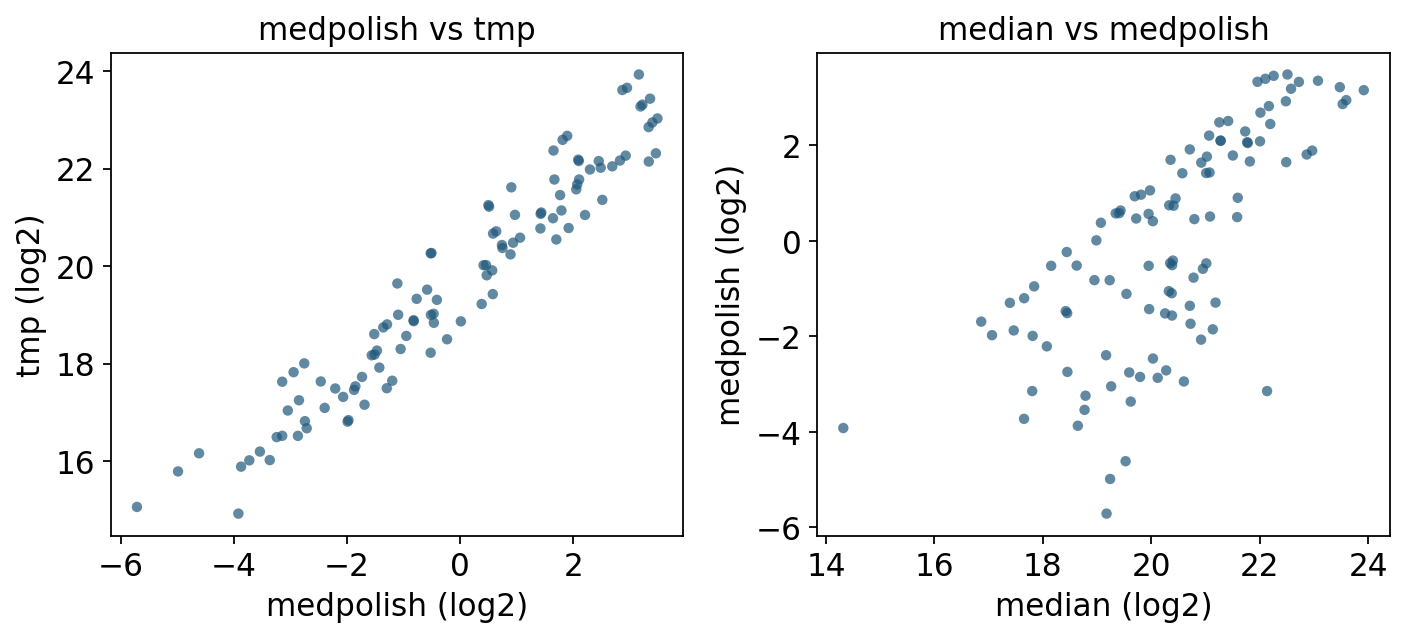

In [13]:
# medpolish vs tmp: both are Tukey median polish, different implementations.
fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))
for ax, (xa, ya) in zip(axes, [('medpolish', 'tmp'), ('median', 'medpolish')]):
    x, y = summ[xa].X.ravel(), summ[ya].X.ravel()
    keep = ~np.isnan(x) & ~np.isnan(y)
    ax.scatter(x[keep], y[keep], s=22, alpha=0.7, edgecolor='none')
    ax.set_xlabel(f'{xa} (log2)'); ax.set_ylabel(f'{ya} (log2)')
    ax.set_title(f'{xa} vs {ya}')
fig.tight_layout(); plt.show()

**Reading the comparison.**

* `medpolish` and `tmp` are the *same* algorithm (Tukey median polish) from two backends; they correlate near-perfectly, differing only by the constant per-protein offset (DEqMS keeps column effects, MSstats adds back the protein mean). Either is a sound default.
* `median` deviates from `medpolish` precisely for proteins with outlier or missing features — the plain median ignores feature effects, so a run that happens to miss the brightest peptides looks lower than it truly is.
* `linear` agrees with TMP when features are clean, but its least-squares fit is pulled by outliers, which is why MSstats replaced it with TMP as the default.

**Recommendation.** Use `medpolish` / `tmp` (robust to outlier peptides, missing-tolerant, the MSstats default) for almost every DDA/DIA experiment. `median` is fine as a fast sanity check or when you have very few peptides per protein. `linear` is mainly for reproducing legacy MSstats results.

## 4. The MSstats `dataProcess` pipeline

In practice you rarely call a summarizer in isolation. MSstats' `dataProcess` bundles the full feature-to-protein preprocessing into one step:

1. **log-transform** the raw intensities (`log_base=2`),
2. **per-run normalization** — `equalizeMedians` shifts each run so its median log-intensity matches the grand median, removing loading / TIC differences,
3. **feature selection** — drop features observed in too few runs (`min_feature_obs`), which would otherwise inject noise,
4. **TMP summarization** — collapse the cleaned feature matrix to protein level via Tukey median polish.

`pymsstats.data_process` takes the MSstats long DataFrame **directly** — it expects exactly the upper-case schema (`ProteinName, PeptideSequence, PrecursorCharge, FragmentIon, ProductCharge, IsotopeLabelType, Condition, BioReplicate, Run, Intensity`), which the `ov.datasets` loader already provides, so no renaming is needed.

In [14]:
import inspect
print('data_process signature:')
print(' ', inspect.signature(pymsstats.data_process))
print('\nrequired columns (pymsstats.CANONICAL_COLS):')
print(' ', pymsstats.CANONICAL_COLS)
print('\nDDA table matches schema:',
      set(pymsstats.CANONICAL_COLS).issubset(dda.columns))

data_process signature:
  (msstats_df: 'pd.DataFrame', *, normalization: 'str' = 'equalizeMedians', summary_method: 'str' = 'TMP', log_base: 'int' = 2, min_feature_obs: 'int' = 2, censored_int: 'str' = 'NA') -> 'pd.DataFrame'

required columns (pymsstats.CANONICAL_COLS):
  ['ProteinName', 'PeptideSequence', 'PrecursorCharge', 'FragmentIon', 'ProductCharge', 'IsotopeLabelType', 'Condition', 'BioReplicate', 'Run', 'Intensity']

DDA table matches schema: True


In [15]:
# Full MSstats preprocessing: log2 + equalizeMedians + feature select + TMP.
msstats_cols = list(pymsstats.CANONICAL_COLS)
processed = pymsstats.data_process(
    dda[msstats_cols],
    normalization='equalizeMedians',
    summary_method='TMP',
    log_base=2,
    min_feature_obs=2,
)
print('processed shape:', processed.shape)
processed.head()

processed shape: (108, 7)


,Protein,RUN,LogIntensities,n_features,n_obs,GROUP,SUBJECT
0,bovine,1,21.349305,14,164,C1,1
1,bovine,10,17.426372,14,164,C4,1
2,bovine,11,17.406355,14,164,C4,1
3,bovine,12,16.390505,14,164,C4,1
4,bovine,13,18.490566,14,164,C5,1


`data_process` returns a **long** protein-level table: one row per `Protein × RUN`, with `LogIntensities` (the summarized protein abundance), `n_features` / `n_obs` (how many features and observations fed each protein), and the design columns `GROUP` / `SUBJECT`. 6 proteins × 18 runs = 108 rows.

We pivot it into the same `runs × proteins` AnnData shape used above, so it can flow into `ov.protein.de` exactly like the `summarize` output.

In [16]:
wide_proc = processed.pivot_table(index='RUN', columns='Protein',
                                  values='LogIntensities', aggfunc='first')
proc_obs = (processed[['RUN', 'GROUP', 'SUBJECT']].drop_duplicates()
            .set_index('RUN').reindex(wide_proc.index))
dp_adata = ad.AnnData(
    X=wide_proc.to_numpy(dtype=float),
    obs=pd.DataFrame({'Condition': proc_obs['GROUP'].astype(str).values},
                     index=wide_proc.index.astype(str)),
    var=pd.DataFrame(index=wide_proc.columns.astype(str)))
print('MSstats dataProcess -> protein AnnData:', dp_adata.shape)
print(dp_adata.obs['Condition'].value_counts().to_string())

MSstats dataProcess -> protein AnnData: (18, 6)
Condition
C1    3
C4    3
C5    3
C6    3
C2    3
C3    3


`dataProcess` and `ov.protein.summarize(method='tmp')` use the same TMP core; `dataProcess` additionally normalizes per run and applies feature filtering, so it is the recommended one-call route for a real MSstats DDA/DIA experiment. `ov.protein.summarize` exposes the individual summarizers so you can compare them — as we did in Section 3.

## 5. Differential expression on the summarized matrix

Summarization produced a protein-level matrix on the log2 scale — exactly the input `ov.protein.de` expects. We take the `medpolish`-summarized AnnData and test one contrast of the spike-in dilution series.

We pick **C2 vs C5**, two well-separated dilution levels. Because the six proteins were spiked at *different* concentrations per condition, a correct summarize → DE pipeline should flag them as differential, with signed fold changes that track the dilution direction.

In [17]:
prot = summ['medpolish']
contrast = prot[prot.obs['Condition'].isin(['C2', 'C5'])].copy()
print('contrast subset:', contrast.shape)
print(contrast.obs['Condition'].value_counts().to_string())

contrast subset: (6, 6)
Condition
C2    3
C5    3


In [18]:
de_dda = ov.protein.de(contrast, group='Condition',
                       method='limma', reference='C2')
de_dda

,gene,logFC,AveExpr,t,P.Value,adj.P.Val
0,chicken,-3.992743,-1.180237,-14.499797,1.215084e-47,7.290506e-47
1,bovine,-3.753528,1.224481,-13.631077,2.616879e-42,7.850637e-42
2,yeast,3.704893,1.138670,13.454457,2.898620e-41,5.797240e-41
3,myg_horse,3.624045,-1.171078,13.160856,1.474069e-39,2.211104e-39
4,cyc_horse,-3.340364,0.279009,-12.130656,7.266499e-34,8.719799e-34
5,rabbit,3.271494,-0.095772,11.880553,1.493758e-32,1.493758e-32


`limma` (Smyth 2004 empirical-Bayes moderated *t*) is appropriate here: with only 3 runs per condition, borrowing variance information across proteins stabilizes the per-protein test. The `logFC` column is `C5 - C2` on the log2 scale. With a controlled spike-in, all six proteins are expected to move — the table confirms the summarized matrix carries real, separable signal.

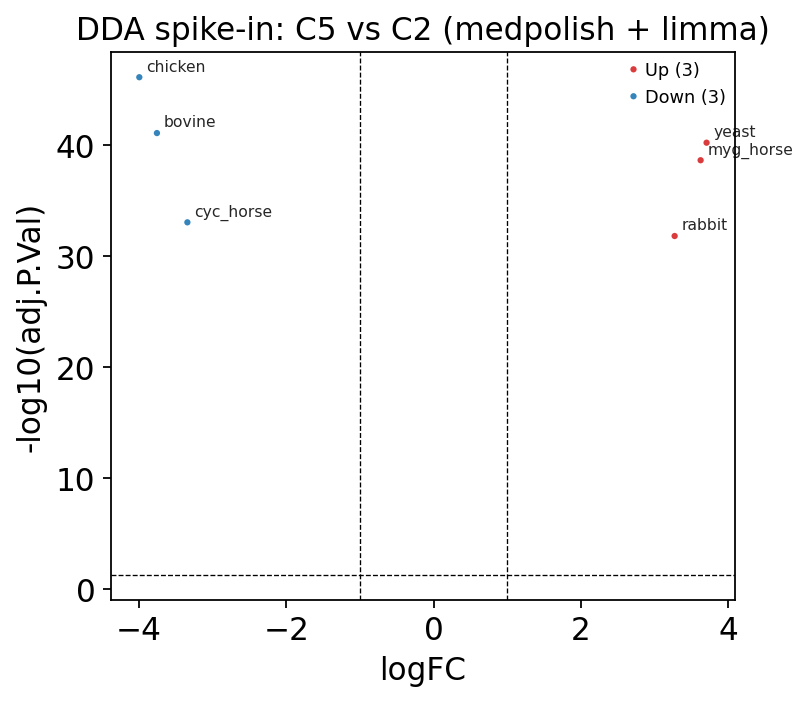

In [19]:
ov.protein.volcano(de_dda, logfc_threshold=1.0, adj_p_threshold=0.05,
                   title='DDA spike-in: C5 vs C2 (medpolish + limma)')
plt.show()

In [20]:
# Does the summarizer choice change the DE call? Re-run on the TMP matrix.
tmp_contrast = summ['tmp'][summ['tmp'].obs['Condition'].isin(['C2', 'C5'])].copy()
de_tmp = ov.protein.de(tmp_contrast, group='Condition',
                       method='limma', reference='C2')
cmp = (de_dda.set_index('gene')[['logFC', 'adj.P.Val']]
       .join(de_tmp.set_index('gene')[['logFC', 'adj.P.Val']],
             lsuffix='_medpolish', rsuffix='_tmp'))
cmp.round(3)

,logFC_medpolish,adj.P.Val_medpolish,logFC_tmp,adj.P.Val_tmp
gene,,,,
chicken,-3.993,0.0,-3.862,0.0
bovine,-3.754,0.0,-3.818,0.0
yeast,3.705,0.0,3.678,0.0
myg_horse,3.624,0.0,3.587,0.0
cyc_horse,-3.340,0.0,-3.324,0.0
rabbit,3.271,0.0,3.231,0.0


The two robust summarizers give near-identical fold changes and significance — reassuring: when the summarizer is robust, the downstream DE is stable. The summarizer choice would matter much more on a noisier, missing-value-heavy dataset, which is exactly why the robust `medpolish`/`tmp` methods are the default.

## 6. The DIA workflow

`ov.datasets.protein_dia()` returns the MSstats `DIARawData` dataset — a real label-free **DIA** experiment comparing *Streptococcus pyogenes* grown at two serum concentrations (`Strep 0%` vs `Strep 10%`), 2 biological replicates each.

**How DIA differs from DDA.** In DDA the instrument picks individual precursors to fragment, so quantification is sparse and stochastic — a precursor missed in one run is simply absent. DIA fragments *all* precursors in wide isolation windows every cycle, giving deeper, more reproducible, more complete quantification. The flip side: DIA spectra are chimeric, so quantification is done at the **fragment-ion (transition)** level — the `FragmentIon` and `ProductCharge` columns are now populated, and the feature is `peptide + charge + fragment + product-charge`.

Crucially, the `ov.protein` workflow is **identical**: the same MSstats long schema, the same `summarize` → `de` path.

In [21]:
dia = ov.datasets.protein_dia()
print('shape:', dia.shape)
print('proteins:', dia['ProteinName'].nunique(),
      '| peptides:', dia['PeptideSequence'].nunique(),
      '| runs:', dia['Run'].nunique())
dia.head()

🔍 Downloading data to ./data/protein_msstats_dia.csv.gz
⚠️ File ./data/protein_msstats_dia.csv.gz already exists
shape: (980, 10)
proteins: 2 | peptides: 32 | runs: 4


,ProteinName,PeptideSequence,PrecursorCharge,FragmentIon,ProductCharge,IsotopeLabelType,Condition,BioReplicate,Run,Intensity
0,RNA helicase exp9,ASPIQEMTIPLALEGK,2,b9,77414,L,Strep 0%,1,1,9747
1,RNA helicase exp9,ASPIQEMTIPLALEGK,2,y10,77411,L,Strep 0%,1,1,1272
2,RNA helicase exp9,ASPIQEMTIPLALEGK,2,y11,77412,L,Strep 0%,1,1,1295
3,RNA helicase exp9,ASPIQEMTIPLALEGK,2,y14,77410,L,Strep 0%,1,1,2332
4,RNA helicase exp9,ASPIQEMTIPLALEGK,2,y7,77409,L,Strep 0%,1,1,8178


In [22]:
# DIA design: 2 conditions x 2 biological replicates.
print(dia[['Run', 'Condition', 'BioReplicate']].drop_duplicates().to_string(index=False))
n_dia_feat = dia.groupby(['ProteinName', 'PeptideSequence', 'PrecursorCharge',
                          'FragmentIon', 'ProductCharge']).ngroups
print(f'\nfragment-level features: {n_dia_feat}')

 Run Condition  BioReplicate
   1  Strep 0%             1
   2  Strep 0%             2
   3 Strep 10%             1
   4 Strep 10%             2

fragment-level features: 245


In [23]:
# Build a fragment-level AnnData: feature = peptide|charge|fragment|prodcharge.
dia = dia.copy()
dia['feature'] = (dia['PeptideSequence'].astype(str) + '|z'
                  + dia['PrecursorCharge'].astype(str) + '|'
                  + dia['FragmentIon'].astype(str) + '|'
                  + dia['ProductCharge'].astype(str))
dia_wide = dia.pivot_table(index='Run', columns='feature',
                           values='Intensity', aggfunc='first')
print('runs × fragment features:', dia_wide.shape)

runs × fragment features: (4, 245)


In [24]:
dia_runmeta = (dia[['Run', 'Condition', 'BioReplicate']]
               .drop_duplicates().set_index('Run').reindex(dia_wide.index))
dia_featmap = (dia[['feature', 'ProteinName']]
               .drop_duplicates().set_index('feature').reindex(dia_wide.columns))
dia_pep = ad.AnnData(
    X=dia_wide.to_numpy(dtype=float),
    obs=pd.DataFrame({'Condition': dia_runmeta['Condition'].astype(str).values},
                     index=dia_wide.index.astype(str)),
    var=pd.DataFrame({'Protein': dia_featmap['ProteinName'].astype(str).values},
                     index=dia_wide.columns.astype(str)))
dia_pep.uns['source'] = 'MSstats DIARawData (S. pyogenes)'
print(dia_pep)

AnnData object with n_obs × n_vars = 4 × 245
    obs: 'Condition'
    var: 'Protein'
    uns: 'source'


In [25]:
# Identical summarize step — collapse 245 fragments to 2 proteins via TMP.
dia_prot = ov.protein.summarize(dia_pep, protein_col='Protein', method='medpolish')
print('DIA protein-level:', dia_prot.shape)
print(pd.DataFrame(dia_prot.X, index=dia_prot.obs_names,
                   columns=dia_prot.var_names).round(3))

DIA protein-level: (4, 2)
protein   FabG  RNA  helicase exp9
Run                               
1        0.882              -0.136
2        0.935               0.130
3       -0.871              -0.308
4       -1.244               0.218


In [26]:
# Identical DE step — Strep 10% vs Strep 0%.
de_dia = ov.protein.de(dia_prot, group='Condition',
                       method='limma', reference='Strep 0%')
de_dia

,gene,logFC,AveExpr,t,P.Value,adj.P.Val
0,FabG,-1.965724,-0.074792,-7.948313,1.890689e-15,3.781377e-15
1,RNA helicase exp9,-0.042263,-0.023843,-0.170887,8.643128e-01,8.643128e-01


In [27]:
# Cross-check with the MSstats dataProcess route on the same DIA data.
dia_processed = pymsstats.data_process(
    dia[list(pymsstats.CANONICAL_COLS)],
    normalization='equalizeMedians', summary_method='TMP', log_base=2)
print('dataProcess DIA output:', dia_processed.shape)
dia_processed[['Protein', 'RUN', 'LogIntensities', 'GROUP']].head(8)

dataProcess DIA output: (8, 7)


,Protein,RUN,LogIntensities,GROUP
0,RNA helicase exp9,1,10.971460,Strep 0%
1,RNA helicase exp9,2,11.102063,Strep 0%
2,RNA helicase exp9,3,11.450784,Strep 10%
3,RNA helicase exp9,4,11.934159,Strep 10%
4,FabG,1,12.446578,Strep 0%
5,FabG,2,12.365709,Strep 0%
6,FabG,3,11.327864,Strep 10%
7,FabG,4,10.944582,Strep 10%


Two proteins, two conditions: `FabG` shows a clear, significant abundance change between the serum conditions while the RNA helicase does not — the expected biological contrast. The point of this section is the **method invariance**: DDA precursor-level data and DIA fragment-level data flow through the *same* `summarize` → `de` (or `dataProcess`) code with nothing changed but how the feature id is constructed.

## Summary

**The peptide → protein step is mandatory.** Search engines emit feature-level (precursor or fragment) intensities; differential testing needs a protein-level matrix. Skipping summarization — or doing it with a naive mean — lets outlier features, non-random missingness and run effects masquerade as biology.

**Which summarizer.**

* `medpolish` / `tmp` (Tukey median polish) — **default choice**. Robust to outlier peptides, missing-tolerant, models feature + run effects jointly. The MSstats default.
* `median` — fast, fully missing-tolerant, but ignores feature effects; good as a sanity check or when peptides per protein are very few.
* `median_sweeping` — removes per-feature offsets before collapsing (TMT-style); returns centred run effects.
* `linear` — least-squares `RUN + FEATURE`; reproduces legacy MSstats but is outlier-sensitive.

**Two routes in omicverse:**

* `ov.protein.summarize(pep_adata, method=...)` — a single summarizer on a feature-level AnnData; use it to *compare* methods.
* `pymsstats.data_process(long_df, ...)` — the full MSstats pipeline (log + per-run normalization + feature filtering + TMP) in one call; the recommended production route for a real DDA/DIA experiment.

**DDA vs DIA.** DIA quantifies at the fragment level and is deeper / more complete, but the omicverse workflow is identical — the same MSstats long schema, the same `summarize` → `de` path.

**Next steps.**

* [Bulk LC-MS/MS best-practice pipeline](t_protein_01_bulk_pipeline.ipynb) — the complete protein-level workflow (QC → imputation → DE → enrichment).
* [Missing values: diagnosis & imputation](t_protein_02_missing_values.ipynb) — handling the non-random dropout seen here.
* [Differential expression: methods compared](t_protein_04_differential_expression.ipynb) — DEqMS vs proDA vs MSstats vs limma, contrasts and power.